<a href="https://colab.research.google.com/github/akash-321/hate-speech-detection-RAG/blob/main/notebooks/model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Two Models Comparison mymodel and IMSyPP

In [19]:
!pip install -q emoji

import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 31.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/dissertation"
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = "/content/drive/MyDrive/dissertation/figures"
import os; os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

### Reading the test of mymodel


In [4]:
import pandas as pd

test_c = pd.read_csv("/content/drive/MyDrive/dissertation/test_with_my_predictions.csv")

print("Number of test comments:", len(test_c))

Number of test comments: 1084


### Running IMSyPP and save it.

In [5]:
from transformers import pipeline


imsypp = pipeline("text-classification", model="IMSyPP/hate_speech_en", truncation=True)

mapping = {"LABEL_0": 0, "LABEL_1": 1, "LABEL_2": 1, "LABEL_3": 1}

predictions = []
for text in test_c["text"]:
    result = imsypp(str(text))[0]
    predictions.append(mapping[result["label"]])

test_c["imsypp_pred"] = predictions

test_c.to_csv("test_predictions_both_models.csv", index=False)

config.json:   0%|          | 0.00/865 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  433MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


### Confusion matrix heatmap

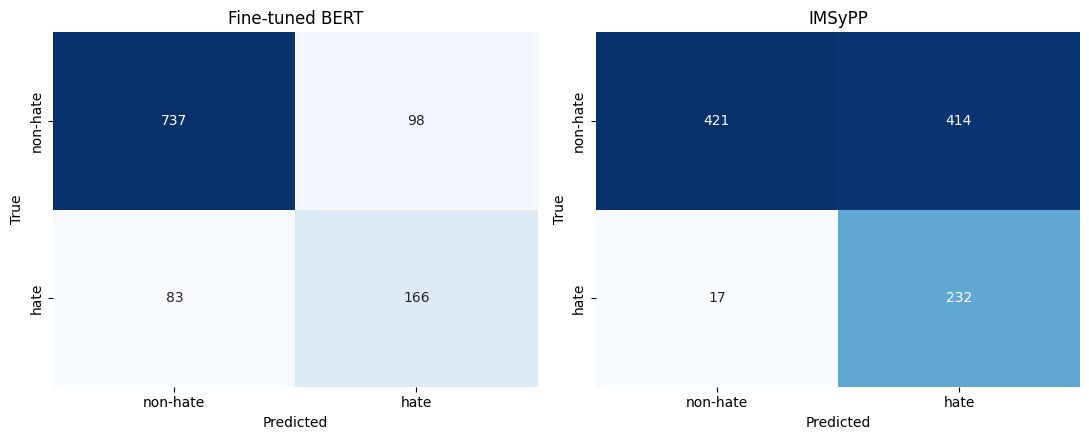

In [6]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, col) in zip(axes, [("Fine-tuned BERT", "my_pred_bin"),
                                  ("IMSyPP", "imsypp_pred")]):
    cm = confusion_matrix(test_c["label_bin"], test_c[col])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["non-hate", "hate"], yticklabels=["non-hate", "hate"], ax=ax)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
save_fig("confusion_matrices")

### Comparison of the models

In [7]:
from sklearn.metrics import accuracy_score, f1_score

true_labels = test_c["label_bin"]

print("My model - accuracy:", round(accuracy_score(true_labels, test_c["my_pred_bin"]), 4))
print("My model - F1 score:", round(f1_score(true_labels, test_c["my_pred_bin"]), 4))
print("IMSyPP - accuracy:", round(accuracy_score(true_labels, test_c["imsypp_pred"]), 4))
print("IMSyPP - F1 score:", round(f1_score(true_labels, test_c["imsypp_pred"]), 4))

My model - accuracy: 0.833
My model - F1 score: 0.6472
IMSyPP - accuracy: 0.6024
IMSyPP - F1 score: 0.5184


### Accuracy comparison by religion

In [8]:
rows = []
for religion in test_c["target_group"].unique():
    subset = test_c[test_c["target_group"] == religion]
    rows.append({
        "religion": religion.replace("target_religion_", ""),
        "n_comments": len(subset),
        "n_hate": int(subset["label_bin"].sum()),
        "my_model": round(accuracy_score(subset["label_bin"], subset["my_pred_bin"]), 4),
        "imsypp": round(accuracy_score(subset["label_bin"], subset["imsypp_pred"]), 4),
    })

group_accuracy = pd.DataFrame(rows).sort_values("my_model")
group_accuracy

,religion,n_comments,n_hate,my_model,imsypp
2,jewish,172,51,0.7791,0.5465
0,muslim,510,134,0.8255,0.6216
3,christian,362,56,0.8591,0.6133
1,atheist,36,7,0.9167,0.4722
4,buddhist,4,1,1.0000,0.7500


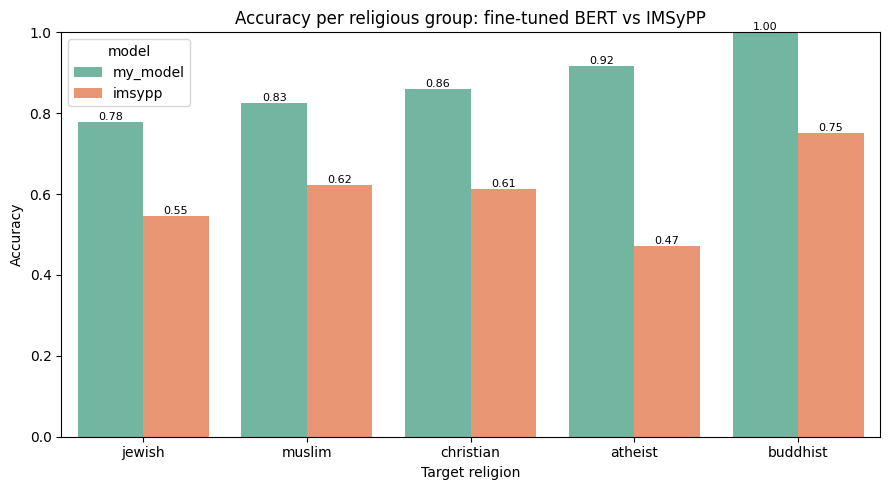

In [9]:
plot_df = group_accuracy.melt(id_vars=["religion", "n_comments"],
                              value_vars=["my_model", "imsypp"],
                              var_name="model", value_name="accuracy")

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=plot_df, x="religion", y="accuracy", hue="model", palette="Set2")
ax.set_ylim(0, 1)
ax.set_xlabel("Target religion"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy per religious group: fine-tuned BERT vs IMSyPP")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)
save_fig("accuracy_per_group")

### FPR and FNR comparison of both models

In [10]:
rows = []
for religion in test_c["target_group"].unique():
    subset = test_c[test_c["target_group"] == religion]

    for model_name, pred_col in [("MyModel", "my_pred_bin"), ("IMSyPP", "imsypp_pred")]:
        true = subset["label_bin"]
        pred = subset[pred_col]

        false_positives = ((true == 0) & (pred == 1)).sum()
        true_negatives = ((true == 0) & (pred == 0)).sum()
        false_negatives = ((true == 1) & (pred == 0)).sum()
        true_positives = ((true == 1) & (pred == 1)).sum()

        fpr = false_positives / (false_positives + true_negatives)
        fnr = false_negatives / (false_negatives + true_positives)

        rows.append({"religion": religion.replace("target_religion_", ""),
                     "model": model_name,
                     "FPR": round(fpr, 4),
                     "FNR": round(fnr, 4)})

fairness_table = pd.DataFrame(rows)
fairness_table

,religion,model,FPR,FNR
0,muslim,MyModel,0.1117,0.3507
1,muslim,IMSyPP,0.4894,0.0672
2,atheist,MyModel,0.0690,0.1429
3,atheist,IMSyPP,0.6552,0.0000
4,jewish,MyModel,0.1736,0.3333
5,jewish,IMSyPP,0.5868,0.1373
6,christian,MyModel,0.1078,0.3214
7,christian,IMSyPP,0.4542,0.0179
8,buddhist,MyModel,0.0000,0.0000
9,buddhist,IMSyPP,0.3333,0.0000


### FPR/FNR bars

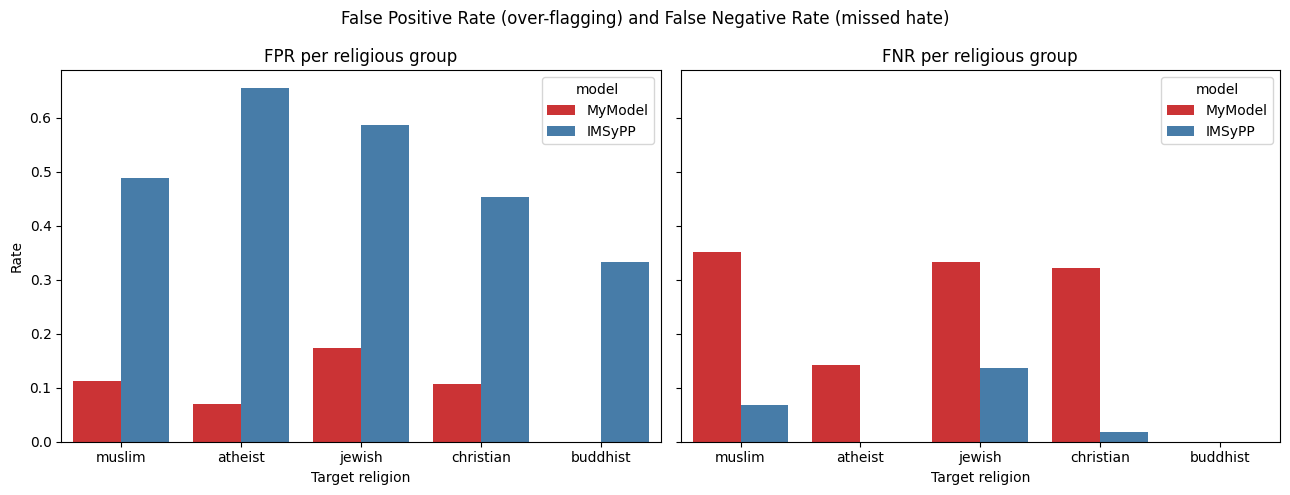

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metric in zip(axes, ["FPR", "FNR"]):
    sns.barplot(data=fairness_table, x="religion", y=metric, hue="model",
                palette="Set1", ax=ax)
    ax.set_title(f"{metric} per religious group")
    ax.set_xlabel("Target religion")
axes[0].set_ylabel("Rate")
plt.suptitle("False Positive Rate (over-flagging) and False Negative Rate (missed hate)")
save_fig("fpr_fnr_per_group")

In [12]:
for model_name in ["MyModel", "IMSyPP"]:
    part = fairness_table[fairness_table["model"] == model_name]
    print(model_name)
    print(" FPR gap:", round(part["FPR"].max() - part["FPR"].min(), 4))
    print(" FNR gap:", round(part["FNR"].max() - part["FNR"].min(), 4))

MyModel
 FPR gap: 0.1736
 FNR gap: 0.3507
IMSyPP
 FPR gap: 0.3219
 FNR gap: 0.1373


### Errors that each models made.

In [13]:
test_c["my_model_wrong"] = test_c["my_pred_bin"] != test_c["label_bin"]
test_c["imsypp_wrong"]   = test_c["imsypp_pred"] != test_c["label_bin"]

both_wrong  = test_c[test_c["my_model_wrong"] & test_c["imsypp_wrong"]]
only_mine   = test_c[test_c["my_model_wrong"] & ~test_c["imsypp_wrong"]]
only_imsypp = test_c[~test_c["my_model_wrong"] & test_c["imsypp_wrong"]]

print("Both models wrong:", len(both_wrong))
print("Only my model wrong:", len(only_mine))
print("Only IMSyPP wrong:", len(only_imsypp))

Both models wrong: 101
Only my model wrong: 80
Only IMSyPP wrong: 330


### Saving examples to read manually.

In [14]:
weak_groups = group_accuracy.head(2)["religion"].tolist()
weak_groups = ["target_religion_" + g for g in weak_groups]

all_errors = test_c[(test_c["my_model_wrong"] | test_c["imsypp_wrong"])
                    & test_c["target_group"].isin(weak_groups)]

samples = []
for religion in weak_groups:
    group_errors = all_errors[all_errors["target_group"] == religion]
    n = max(1, len(group_errors) // 3)
    samples.append(group_errors.sample(n=n, random_state=42))

qualitative_sample = pd.concat(samples)
qualitative_sample.to_csv("qualitative_errors_sample.csv", index=False)
print("Saved", len(qualitative_sample), "examples to read manually")

Saved 110 examples to read manually


### loading raw test annotations and identifying the vote column

In [15]:
# Raw annotation-level test split (one row per annotation, not per comment)
test_raw = pd.read_csv(f"{SAVE_DIR}/test.csv")

print("Columns:", test_raw.columns.tolist())
print("\nRows (annotations):", len(test_raw))
print("Unique comments:", test_raw["comment_id"].nunique())
print("\nAnnotator group counts:")
print(test_raw["annotator_group"].value_counts())

# The majority vote needs each annotator's INDIVIDUAL judgement.
if "hatespeech" in test_raw.columns:
    print("\n'hatespeech' column found — using it for votes (2 = hate).")
    test_raw["vote_hate"] = (test_raw["hatespeech"] == 2).astype(int)
else:
    print("\nWARNING: no 'hatespeech' column. Check the printout above for a per-annotation")
    print("label column and set vote_hate accordingly before continuing.")

Columns: ['comment_id', 'annotator_id', 'platform', 'sentiment', 'respect', 'insult', 'humiliate', 'status', 'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech', 'hate_speech_score', 'text', 'infitms', 'outfitms', 'annotator_severity', 'std_err', 'annotator_infitms', 'annotator_outfitms', 'hypothesis', 'target_race_asian', 'target_race_black', 'target_race_latinx', 'target_race_middle_eastern', 'target_race_native_american', 'target_race_pacific_islander', 'target_race_white', 'target_race_other', 'target_race', 'target_religion_atheist', 'target_religion_buddhist', 'target_religion_christian', 'target_religion_hindu', 'target_religion_jewish', 'target_religion_mormon', 'target_religion_muslim', 'target_religion_other', 'target_religion', 'target_origin_immigrant', 'target_origin_migrant_worker', 'target_origin_specific_country', 'target_origin_undocumented', 'target_origin_other', 'target_origin', 'target_gender_men', 'target_gender_non_binary', 'target_gender_transgen

### Building one test set per annotator religious group

In [20]:
import re, emoji

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "[URL]", text)
    text = re.sub(r"@\w+", "[USER]", text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [21]:
annotator_religions = ["muslim", "christian", "jewish", "atheist", "buddhist"]

annotator_sets = {}
summary_rows = []

for religion in annotator_religions:
    sub = test_raw[test_raw["annotator_group"] == religion]

    grp = (sub.groupby("comment_id")
              .agg(text=("text", "first"),
                   n_ann=("vote_hate", "size"),
                   votes_hate=("vote_hate", "sum"))
              .reset_index())

    grp = grp[grp["n_ann"] >= 3].copy()                    # min-annotation rule
    grp = grp[grp["votes_hate"] * 2 != grp["n_ann"]]       # drop exact ties
    grp["label_bin"] = (grp["votes_hate"] * 2 > grp["n_ann"]).astype(int)
    grp["text"] = grp["text"].map(preprocess)              # same preprocessing as everywhere

    annotator_sets[religion] = grp
    summary_rows.append({
        "annotator_group": religion,
        "n_comments": len(grp),
        "n_hate": int(grp["label_bin"].sum()),
        "hate_pct": round(grp["label_bin"].mean() * 100, 1) if len(grp) else 0,
        "reliability_flag": "SMALL (<100)" if len(grp) < 100 else "ok",
    })

set_summary = pd.DataFrame(summary_rows)
display(set_summary)
set_summary.to_csv(f"{SAVE_DIR}/annotator_testset_summary.csv", index=False)

,annotator_group,n_comments,n_hate,hate_pct,reliability_flag
0,muslim,3,2,66.7,SMALL (<100)
1,christian,46,12,26.1,SMALL (<100)
2,jewish,5,4,80.0,SMALL (<100)
3,atheist,11,6,54.5,SMALL (<100)
4,buddhist,5,4,80.0,SMALL (<100)


### Predictions from both models on each group's test set

In [22]:

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

tokenizer = AutoTokenizer.from_pretrained(f"{SAVE_DIR}/bert_finetuned_final")
my_model = AutoModelForSequenceClassification.from_pretrained(f"{SAVE_DIR}/bert_finetuned_final")
device = "cuda" if torch.cuda.is_available() else "cpu"
my_model.to(device).eval()

def predict_binary(texts, batch_size=32):
    preds = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i+batch_size], truncation=True, padding=True,
                        max_length=256, return_tensors="pt").to(device)
        with torch.no_grad():
            p3 = my_model(**enc).logits.argmax(dim=-1).cpu().numpy()
        preds.extend((p3 == 2).astype(int))
    return np.array(preds)

imsypp = pipeline("text-classification", model="IMSyPP/hate_speech_en",
                  truncation=True, max_length=512, batch_size=32,
                  device=0 if torch.cuda.is_available() else -1)
imsypp_to_binary = {"LABEL_0": 0, "LABEL_1": 1, "LABEL_2": 1, "LABEL_3": 1}

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### main result table

In [24]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def fpr_fnr(y_true, y_pred):
    tn = ((y_true == 0) & (y_pred == 0)).sum(); fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum(); tp = ((y_true == 1) & (y_pred == 1)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    return fpr, fnr

rows = []
for religion, grp in annotator_sets.items():
    if len(grp) == 0:
        continue
    grp["my_pred_bin"] = predict_binary(grp["text"].tolist())
    grp["imsypp_pred"] = [imsypp_to_binary[r["label"]] for r in imsypp(grp["text"].tolist())]
    grp.to_csv(f"{SAVE_DIR}/annotator_testset_{religion}.csv", index=False)

    y = grp["label_bin"].values
    for model_name, col in [("mymodel", "my_pred_bin"), ("IMSyPP", "imsypp_pred")]:
        fpr, fnr = fpr_fnr(y, grp[col].values)
        rows.append({
            "annotator_group": religion, "model": model_name,
            "n": len(grp), "n_hate": int(y.sum()),
            "accuracy": round(accuracy_score(y, grp[col]), 4),
            "f1_macro": round(f1_score(y, grp[col], average="macro"), 4),
            "FPR": round(fpr, 4), "FNR": round(fnr, 4),
        })
        print(f"{religion} / {model_name} confusion matrix:")
        print(confusion_matrix(y, grp[col]), "\n")

annotator_results = pd.DataFrame(rows)
display(annotator_results)
annotator_results.to_csv(f"{SAVE_DIR}/annotator_religion_results.csv", index=False)

muslim / mymodel confusion matrix:
[[1 0]
 [0 2]] 

muslim / IMSyPP confusion matrix:
[[1 0]
 [0 2]] 

christian / mymodel confusion matrix:
[[32  2]
 [ 2 10]] 

christian / IMSyPP confusion matrix:
[[17 17]
 [ 3  9]] 

jewish / mymodel confusion matrix:
[[1 0]
 [0 4]] 

jewish / IMSyPP confusion matrix:
[[1 0]
 [1 3]] 

atheist / mymodel confusion matrix:
[[4 1]
 [0 6]] 

atheist / IMSyPP confusion matrix:
[[1 4]
 [1 5]] 

buddhist / mymodel confusion matrix:
[[1 0]
 [0 4]] 

buddhist / IMSyPP confusion matrix:
[[1 0]
 [1 3]] 



,annotator_group,model,n,n_hate,accuracy,f1_macro,FPR,FNR
0,muslim,mymodel,3,2,1.0000,1.0000,0.0000,0.0000
1,muslim,IMSyPP,3,2,1.0000,1.0000,0.0000,0.0000
2,christian,mymodel,46,12,0.9130,0.8873,0.0588,0.1667
3,christian,IMSyPP,46,12,0.5652,0.5517,0.5000,0.2500
4,jewish,mymodel,5,4,1.0000,1.0000,0.0000,0.0000
5,jewish,IMSyPP,5,4,0.8000,0.7619,0.0000,0.2500
6,atheist,mymodel,11,6,0.9091,0.9060,0.2000,0.0000
7,atheist,IMSyPP,11,6,0.5455,0.4762,0.8000,0.1667
8,buddhist,mymodel,5,4,1.0000,1.0000,0.0000,0.0000
9,buddhist,IMSyPP,5,4,0.8000,0.7619,0.0000,0.2500


### fairness gap

In [27]:
print("Fairness gaps across ANNOTATOR religious groups (max - min):")
print("Groups with undefined rates (no hate or no non - hate comments) are excluded and listed.\n")

for model_name in ["FineTuned", "IMSyPP"]:
    sub = annotator_results[annotator_results["model"] == model_name]
    print(f"{model_name}:")
    for metric in ["FPR", "FNR", "f1_macro"]:
        valid = sub.dropna(subset=[metric])
        excluded = sub[sub[metric].isna()]["annotator_group"].tolist()
        if len(valid) >= 2:
            gap = valid[metric].max() - valid[metric].min()
            note = f" (excluded: {excluded})" if excluded else ""
            print(f" {metric} gap: {gap:.4f} over {len(valid)} groups{note}")
        else:
            print(f" {metric} gap: not computable - fewer than 2 valid groups")
    print()

display(annotator_results[["annotator_group", "model", "n", "n_hate", "FPR", "FNR", "f1_macro"]])

Fairness gaps across ANNOTATOR religious groups (max - min):
Groups with undefined rates (no hate or no non-hate comments) are excluded and listed.

FineTuned:
  FPR gap: not computable — fewer than 2 valid groups
  FNR gap: not computable — fewer than 2 valid groups
  f1_macro gap: not computable — fewer than 2 valid groups

IMSyPP:
  FPR gap: 0.8000 over 5 groups
  FNR gap: 0.2500 over 5 groups
  f1_macro gap: 0.5238 over 5 groups



,annotator_group,model,n,n_hate,FPR,FNR,f1_macro
0,muslim,mymodel,3,2,0.0000,0.0000,1.0000
1,muslim,IMSyPP,3,2,0.0000,0.0000,1.0000
2,christian,mymodel,46,12,0.0588,0.1667,0.8873
3,christian,IMSyPP,46,12,0.5000,0.2500,0.5517
4,jewish,mymodel,5,4,0.0000,0.0000,1.0000
5,jewish,IMSyPP,5,4,0.0000,0.2500,0.7619
6,atheist,mymodel,11,6,0.2000,0.0000,0.9060
7,atheist,IMSyPP,11,6,0.8000,0.1667,0.4762
8,buddhist,mymodel,5,4,0.0000,0.0000,1.0000
9,buddhist,IMSyPP,5,4,0.0000,0.2500,0.7619


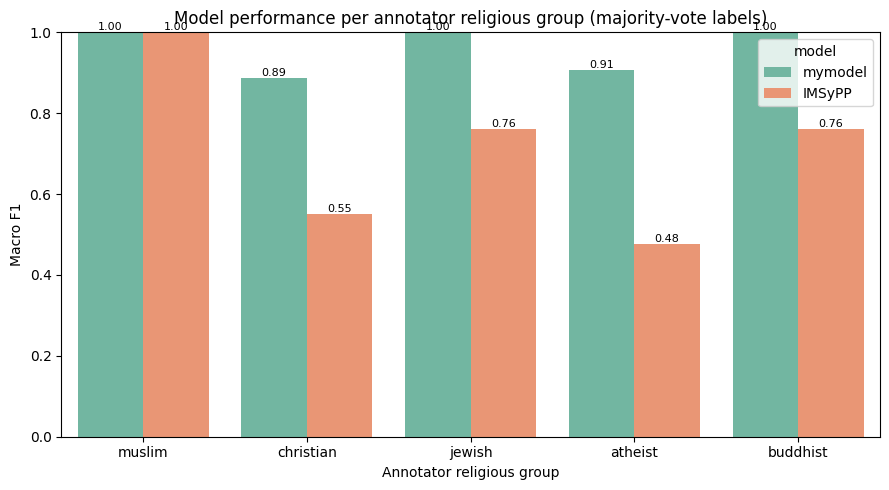

In [28]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=annotator_results, x="annotator_group", y="f1_macro",
                 hue="model", palette="Set2")
ax.set_ylim(0, 1)
ax.set_xlabel("Annotator religious group"); ax.set_ylabel("Macro F1")
ax.set_title("Model performance per annotator religious group (majority-vote labels)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)
save_fig("annotator_group_f1")